In [7]:
# Movie Analysis Pipeline
#This notebook provides a clean, atomic pipeline for fetching, cleaning, and analyzing movie data from the TMDB API.


In [24]:
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

# Ensure project root is in path
project_root = Path.cwd()
if project_root.name != "TMDB":
    candidate = project_root / "TMDB"
    if candidate.exists():
        project_root = candidate
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from api.api import TMDB
from processing.clean_movies import clean_movies
from analysis.kpi_analysis import compute_profit, rank_kpi
from visualization.plots import (
    plot_revenue_vs_budget,
    plot_roi_by_genre,
    plot_popularity_vs_rating,
    plot_yearly_revenue_trends,
    plot_franchise_vs_standalone,
)


In [9]:
## 1. Data Ingestion
#Fetch movie data from the TMDB API using concurrent requests.


In [10]:
movie_ids = [
    299534, 19995, 140607, 299536, 597, 135397, 420818, 24428, 168259,
    99861, 284054, 12445, 181808, 330457, 351286, 109445, 321612, 260513,
]

tmdb = TMDB()
movies_payload = await tmdb.get_movies_batch_async(movie_ids, max_concurrent=4)
raw_df = pd.json_normalize(movies_payload, max_level=0)

print(f"Fetched {len(raw_df)} records.")
display(raw_df.head(3))


INFO:api.api:TMDB API client initialized successfully.
ERROR:api.api:Error fetching movie 299534: 
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/19995?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/597?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:api.api:Fetched movie 597 with credits
INFO:api.api:Fetched movie 19995 with credits
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/140607?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:api.api:Fetched movie 140607 with credits
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/299536?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/135397?api_key=8b3fa69ac

Fetched 17 records.


,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,credits
0,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,"{'id': 87096, 'name': 'Avatar Collection', 'po...",237000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,...,2923706026,162,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Enter the world of Pandora.,Avatar,False,7.600,33701,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."
1,False,/8BTsTfln4jlQrLXUBquXJ0ASQy9.jpg,"{'id': 10, 'name': 'Star Wars Collection', 'po...",245000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,...,2068223624,136,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.249,20402,"{'cast': [{'adult': False, 'gender': 1, 'id': ..."
2,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",300000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,...,2052415039,149,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.200,31678,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."


In [11]:
## 2. Data Cleaning
#Preprocess raw data: extract nested fields, handle missing values, and validate schema.


In [12]:
clean_df = clean_movies(raw_df)
print(f"Rows after cleaning: {len(clean_df)}")
display(clean_df.head(3))


Rows after cleaning: 17


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
0,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,7.600,44.2069,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,998
1,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,...,7.249,10.7997,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,265
2,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure|Action|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,8.200,46.8444,149,As the Avengers and their allies have continue...,English|,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo,738


In [13]:
## 3. KPI Analysis
#Compute metrics like Profit and ROI, and generate rankings.


In [27]:
kpi_df = compute_profit(clean_df).copy()


In [28]:
print("\n=== Highest Revenue ===")
display(rank_kpi(kpi_df, "revenue_musd"))



=== Highest Revenue ===


,id,title,revenue_musd
0,19995,Avatar,2923.706026
3,597,Titanic,2264.162353
1,140607,Star Wars: The Force Awakens,2068.223624
2,299536,Avengers: Infinity War,2052.415039
4,135397,Jurassic World,1671.537444


In [29]:
print("\n=== Highest Profit ===")
display(rank_kpi(kpi_df, "profit_musd"))



=== Highest Profit ===


,id,title,profit_musd
0,19995,Avatar,2686.706026
3,597,Titanic,2064.162353
1,140607,Star Wars: The Force Awakens,1823.223624
2,299536,Avengers: Infinity War,1752.415039
4,135397,Jurassic World,1521.537444


In [ ]:
print("\n=== Highest ROI (budget >= 10M) ===")
display(rank_kpi(kpi_df[kpi_df["budget_musd"] >= 10], "roi"))


In [ ]:
print("\n=== Most Popular ===")
display(rank_kpi(kpi_df, "popularity"))


In [15]:
## 4. Visualization
#Generate and display insight plots using Seaborn-enhanced visualization module.


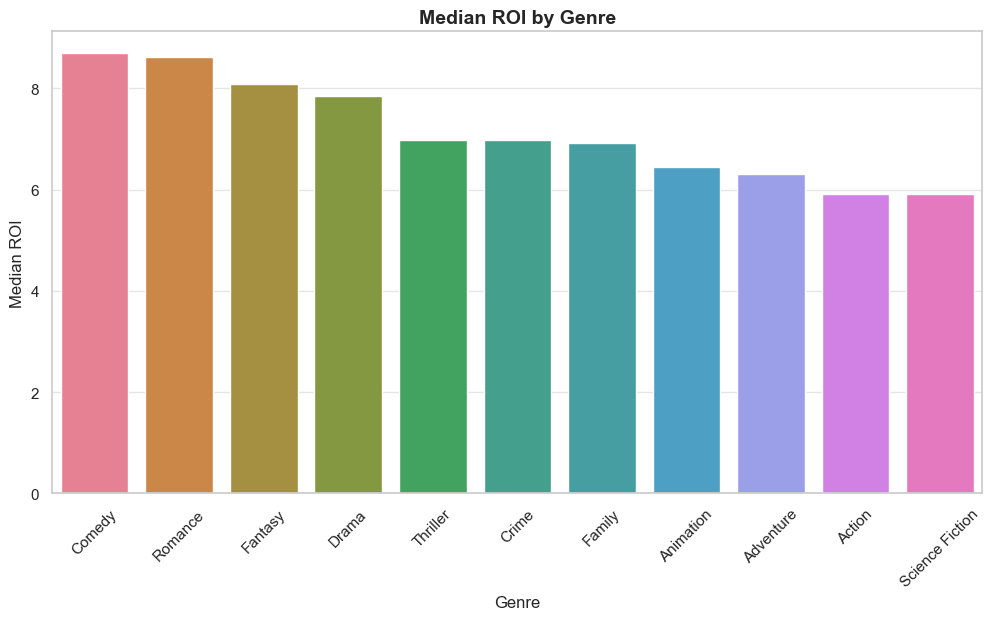

In [16]:
plot_roi_by_genre(kpi_df)

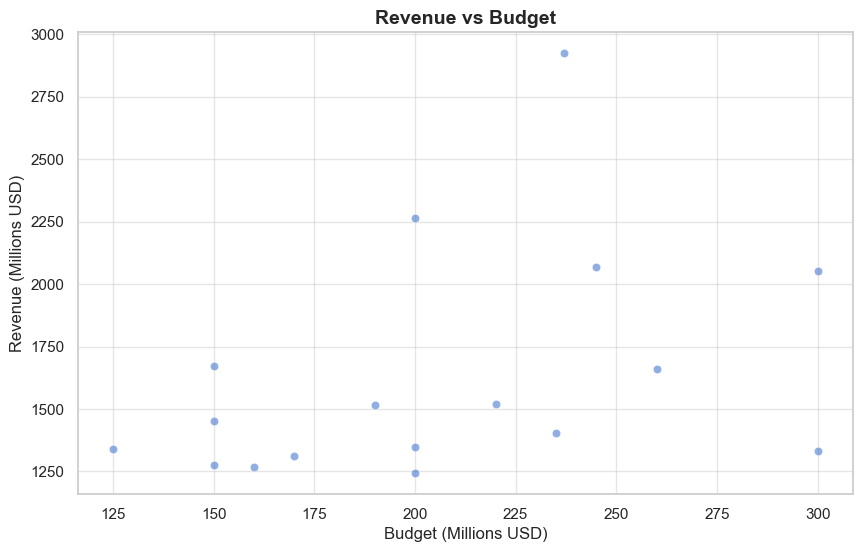

In [25]:
plot_revenue_vs_budget(kpi_df)

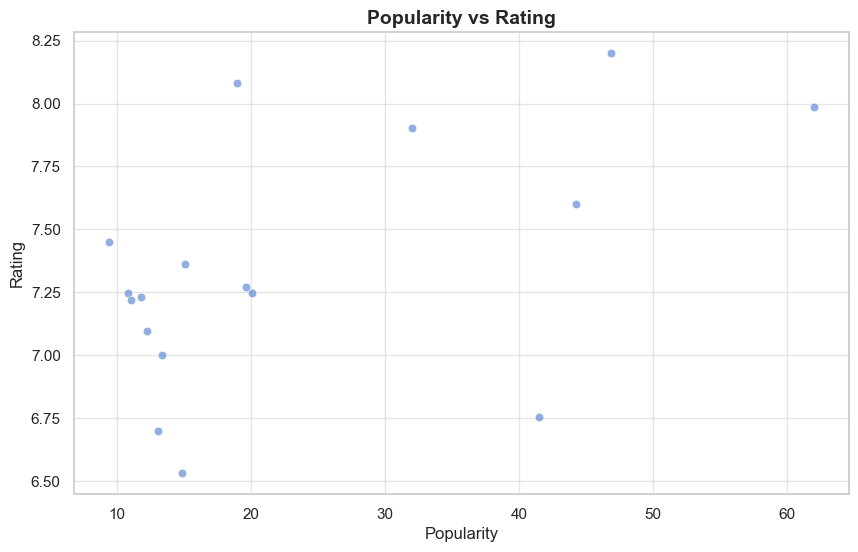

In [26]:
plot_popularity_vs_rating(kpi_df)

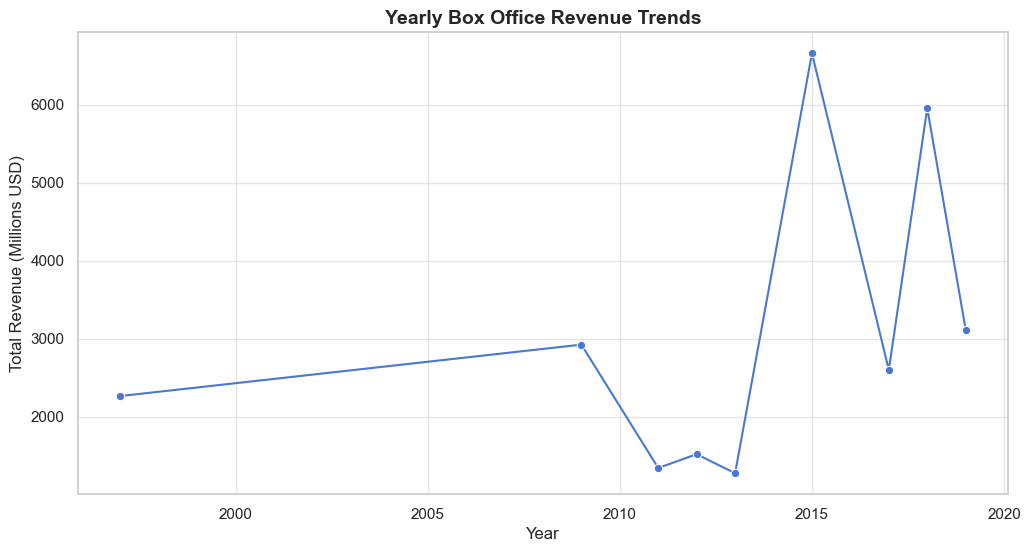

In [19]:
plot_yearly_revenue_trends(kpi_df)

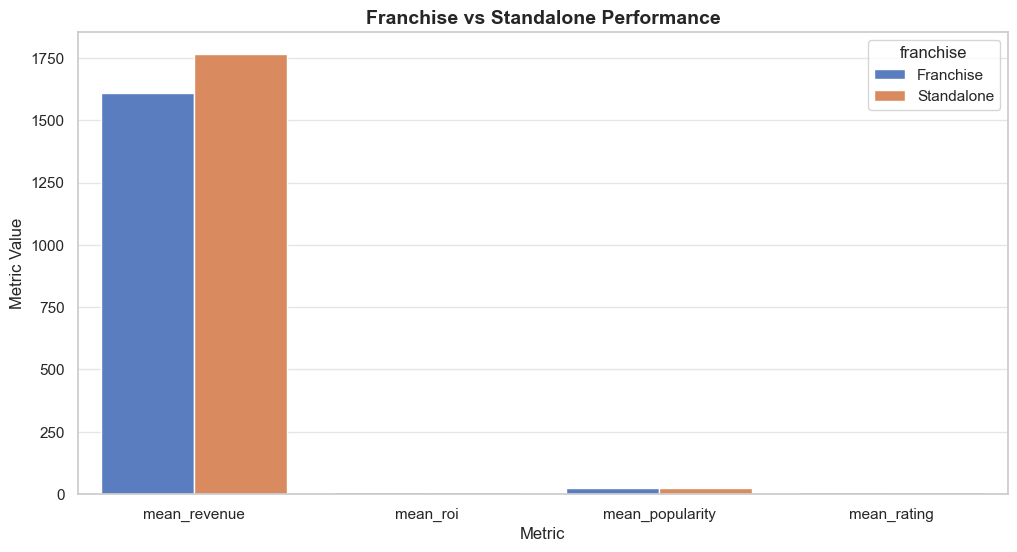

In [20]:
plot_franchise_vs_standalone(kpi_df)